In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
import numpy as np

In [51]:
# Cargar el archivo
df = pd.read_csv('violencia_unite_data.csv')

# Convertir 'CONDUCENTE' a binario: 1.0 -> 1, 2.0 o 9.0 -> 0
df['CONDUCENTE'] = df['CONDUCENTE'].replace({2.0: 0, 9.0: 0})

# Eliminar filas con valores nulos en la variable objetivo
df = df.dropna(subset=['CONDUCENTE'])

In [52]:
# Variable objetivo
y = df['CONDUCENTE']

# Selección de características (puedes ajustar estas)
X = df[[
    'REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD',
    'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
    'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP',
    'HEC_DEP', 'HEC_MUNI', 'HEC_AREA'
]]


In [53]:
# Separar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Crear transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Deja pasar columnas numéricas tal cual
)


In [54]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (18128, 15)
X_test shape: (4533, 15)
y_train shape: (18128,)
y_test shape: (4533,)


In [55]:
# Pipeline con preprocesamiento y regresión logística
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Entrenar el modelo
model.fit(X_train, y_train)

C:\Users\dgv31\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\dgv31\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remain

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [56]:
# Predicciones
y_pred = model.predict(X_test)

# Evaluación
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.30      0.42      1685
         1.0       0.69      0.92      0.79      2848

    accuracy                           0.69      4533
   macro avg       0.68      0.61      0.60      4533
weighted avg       0.69      0.69      0.65      4533



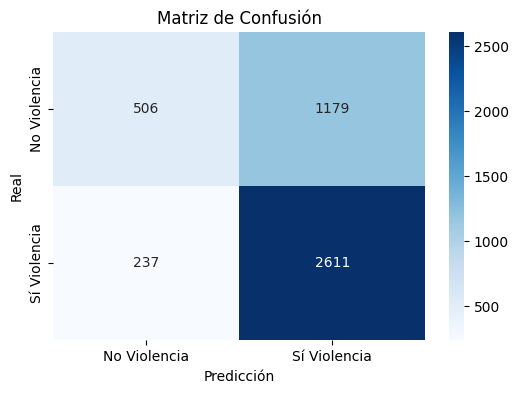

In [57]:
# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Violencia", "Sí Violencia"],
            yticklabels=["No Violencia", "Sí Violencia"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

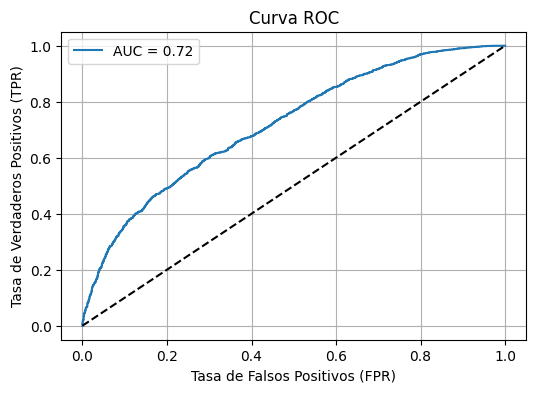

In [58]:
# Obtener probabilidades de clase positiva
y_prob = model.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Visualización
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # Línea base
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()


## Normalización

In [59]:
# Variables numéricas y categóricas
num_features = ['VIC_EDAD', 'AGR_EDAD', 'VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']
cat_features = ['REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'AGR_SEXO', 'VIC_GRUPET', 'AGR_GRUPET',
                'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP', 'HEC_DEP', 'HEC_MUNI', 'HEC_AREA']

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])


In [60]:
sexo_edad_cols = ['VIC_EDADMUJ', 'VIC_EDADHOM', 'AGR_EDADMUJ', 'AGR_EDADHOM']
df[sexo_edad_cols] = df[sexo_edad_cols].fillna(0)

# Separar X e y
X = df.drop('CONDUCENTE', axis=1)
y = df['CONDUCENTE'].replace({2.0: 0.0, 9.0: 0.0, 1.0: 1.0})  # Asegura que las clases estén bien definidas

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Entrenar
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC
y_prob = model.predict_proba(X_test)[:, 1]
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob):.2f}")


Confusion Matrix:
 [[1579  833]
 [1688 2699]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.48      0.65      0.56      2412
         1.0       0.76      0.62      0.68      4387

    accuracy                           0.63      6799
   macro avg       0.62      0.63      0.62      6799
weighted avg       0.66      0.63      0.64      6799


ROC AUC Score: 0.71


In [61]:
print(df['CONDUCENTE'].value_counts(normalize=True))

CONDUCENTE
1.0    0.645294
0.0    0.354706
Name: proportion, dtype: float64



Confusion Matrix:
 [[ 921 1491]
 [ 562 3825]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.62      0.38      0.47      2412
         1.0       0.72      0.87      0.79      4387

    accuracy                           0.70      6799
   macro avg       0.67      0.63      0.63      6799
weighted avg       0.68      0.70      0.68      6799


ROC AUC Score: 0.7137388337546369


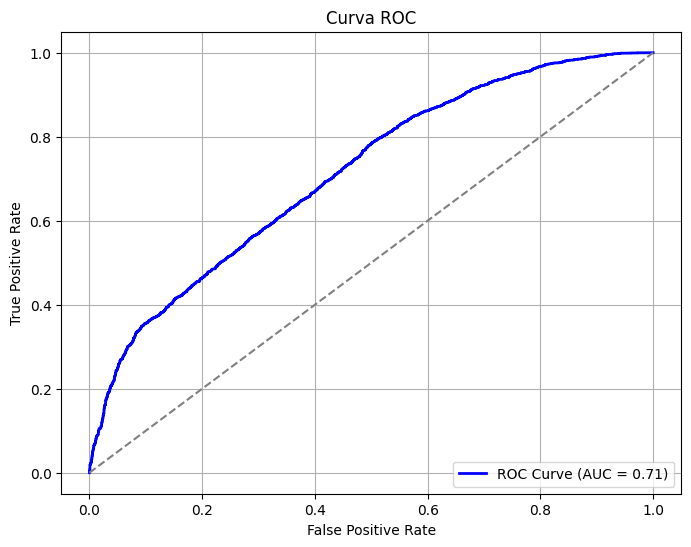

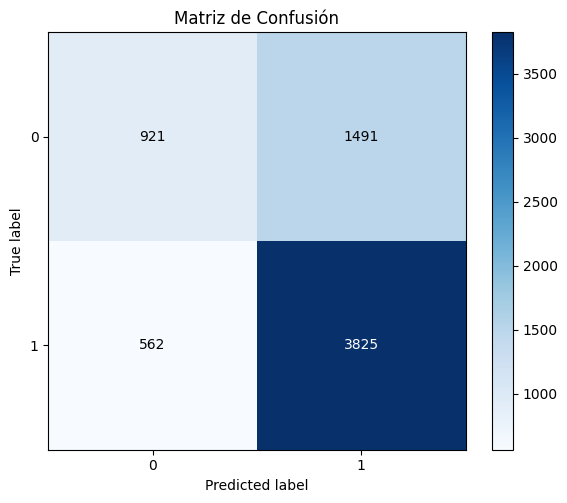

In [ ]:
# 1. Obtener las probabilidades de clase positiva
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Ajustar el umbral (por ejemplo, 0.4 en vez de 0.5)
umbral = 0.4
y_pred = (y_proba >= umbral).astype(int)

# 3. Evaluar el modelo
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

# --- GRÁFICA ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- MATRIZ DE CONFUSIÓN ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()
classes = [0, 1]  # Cambia según los valores únicos de tu variable objetivo
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

# Etiquetas de la matriz de confusión
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center", color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()
